In [5]:
# Libaries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

### Data Acquisition and Loading

In [6]:
# Define path
data_path = '../data/OnlineNewsPopularity.csv'

# Check if file exists locally, if not download from Kaggle
if not os.path.exists(data_path):
    print('File not found locally. Downloading from Kaggle...')
    import kagglehub
    # Download latest version
    path = kagglehub.dataset_download('thehapyone/uci-online-news-popularity-data-set')
    print('Path to dataset files:', path)
    # Update data_path to the downloaded location
    import glob
    csv_files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
    if csv_files:
        data_path = csv_files[0]

# Load dataset
df = pd.read_csv(data_path)

# Strip whitespace from column names (UCI dataset has leading spaces)
df.columns = df.columns.str.strip()

print(f'Dataset Shape: {df.shape}')
print(f'Number of Features: {df.shape[1]}')
print(f'Number of Records: {df.shape[0]}')
df.head()

Dataset Shape: (39644, 61)
Number of Features: 61
Number of Records: 39644


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### Basic Dataset Overview

In [7]:
# Basic Dataset Overview
print('Data Types:')
print(df.dtypes)
print(f'\nTotal Columns: {len(df.columns)}')

Data Types:
url                                 str
timedelta                       float64
n_tokens_title                  float64
n_tokens_content                float64
n_unique_tokens                 float64
                                 ...   
title_subjectivity              float64
title_sentiment_polarity        float64
abs_title_subjectivity          float64
abs_title_sentiment_polarity    float64
shares                            int64
Length: 61, dtype: object

Total Columns: 61


### Statistical Summary

In [8]:
# View Statistical Summary
df.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


### Missing Value Check

In [9]:
# Check missing values
missing = df.isnull().sum()
print(f'Total Missing Values: {missing.sum()}')

if missing.sum() == 0:
    print('No missing values found')
else:
    print(missing[missing > 0])

Total Missing Values: 0
No missing values found


### Target Definition and Distribution

In [10]:
# Create binary target
THRESHOLD = 1400  # Median value
df['popularity'] = (df['shares'] >= THRESHOLD).astype(int)

# Class distribution
class_counts = df['popularity'].value_counts()
print('Class Distribution:')
print(f'Not Popular (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)')
print(f'Popular (1):     {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)')

Class Distribution:
Not Popular (0): 18490 (46.6%)
Popular (1):     21154 (53.4%)


### Class Distribution Visualization

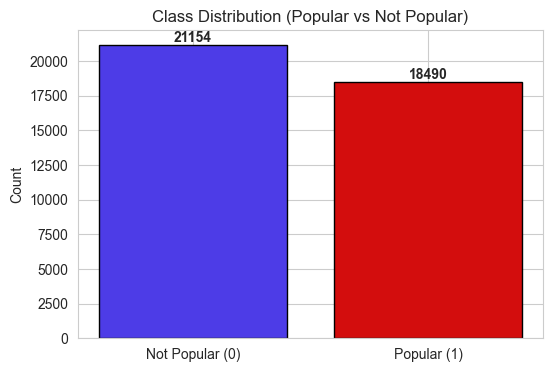

In [11]:
# Plot class distribution
import os
os.makedirs('../docs', exist_ok=True)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Not Popular (0)', 'Popular (1)'], class_counts.values,
               color=["#4d3ce7", "#d30d0d"], edgecolor='black')
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             str(count), ha='center', fontweight='bold')
plt.title('Class Distribution (Popular vs Not Popular)')
plt.ylabel('Count')
plt.savefig('../docs/class_distribution.png', dpi=150)
plt.show()

### Correlation Heatmap

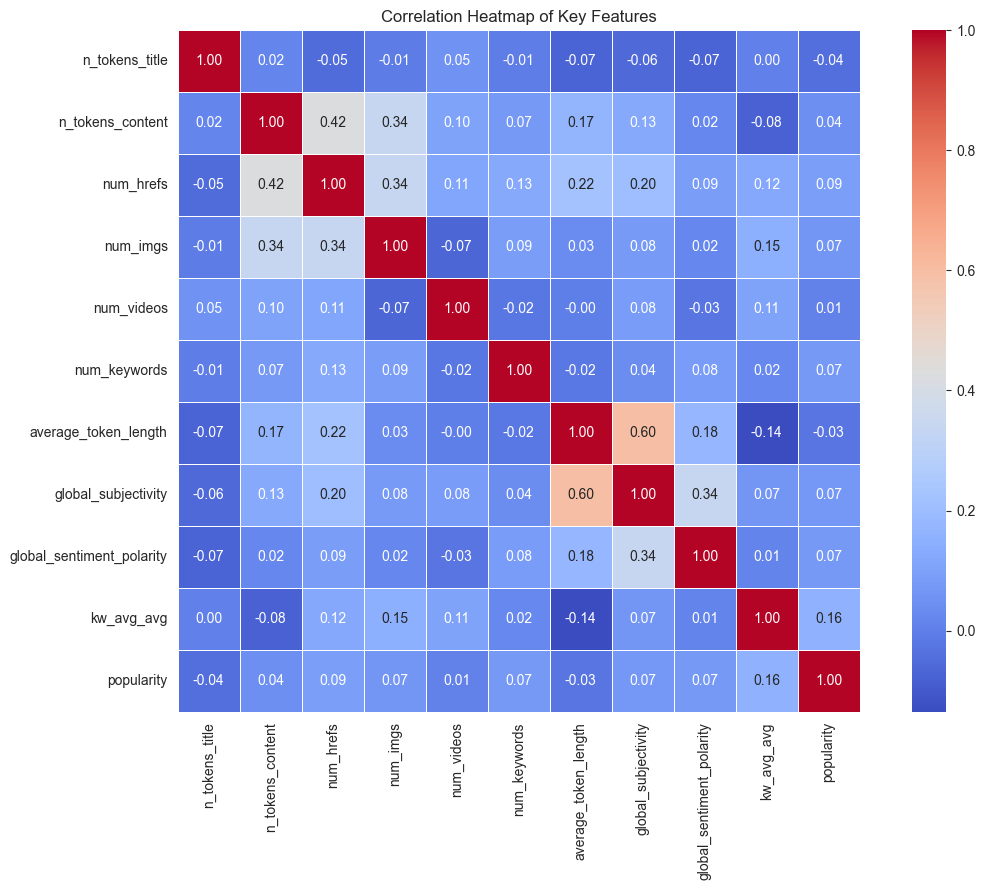

In [12]:
# Correlation Heatmap
import os
os.makedirs('../docs', exist_ok=True)

# Select a subset of important numeric features for correlation
key_features = [
    'n_tokens_title', 'n_tokens_content', 'num_hrefs',
    'num_imgs', 'num_videos', 'num_keywords',
    'average_token_length', 'global_subjectivity',
    'global_sentiment_polarity', 'kw_avg_avg', 'popularity'
]

plt.figure(figsize=(12, 9))
corr_matrix = df[key_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Key Features')
plt.tight_layout()
plt.savefig('../docs/correlation_heatmap.png', dpi=150)
plt.show()

### Feature Engineering and Preprocessing

In [13]:
# Feature Engineering & Preprocessing
# Drop non-feature columns
df_model = df.drop(columns=['url', 'shares', 'timedelta'])

# Separate features and target
X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

print(f'Feature Matrix Shape: {X.shape}')
print(f'Target Vector Shape:  {y.shape}')
print(f'Number of Features:   {X.shape[1]}')

Feature Matrix Shape: (39644, 58)
Target Vector Shape:  (39644,)
Number of Features:   58


### Train-Test Splitting

In [14]:
# Train-Test Split
# 80/20 split, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training Set Size: {X_train.shape[0]} samples')
print(f'Test Set Size:     {X_test.shape[0]} samples')
print(f'Train Class Balance: {y_train.value_counts().to_dict()}')
print(f'Test Class Balance:  {y_test.value_counts().to_dict()}')

Training Set Size: 31715 samples
Test Set Size:     7929 samples
Train Class Balance: {1: 16923, 0: 14792}
Test Class Balance:  {1: 4231, 0: 3698}


### Feature Scaling

In [15]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling applied (StandardScaler)')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')

Feature scaling applied (StandardScaler)
X_train_scaled shape: (31715, 58)
X_test_scaled shape:  (7929, 58)


### Explore Feature Distributions
We will visualize the distribution of three key numerical features: content length, number of links, and the average keyword performance.

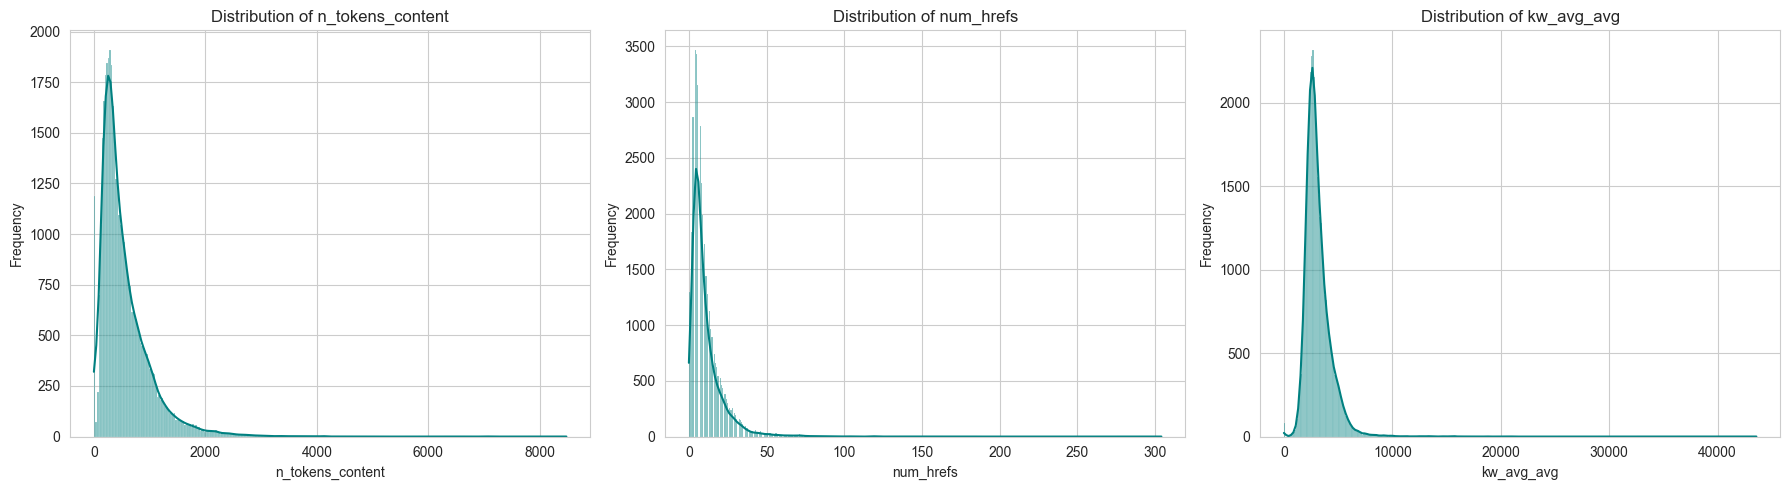

In [17]:
# Select features to visualize
features_to_plot = ['n_tokens_content', 'num_hrefs', 'kw_avg_avg']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Visualize Relationships Between Features
#### Scatter plots
We will examine how pairs of features relate to each other and whether they help distinguish between popular and non-popular news items.

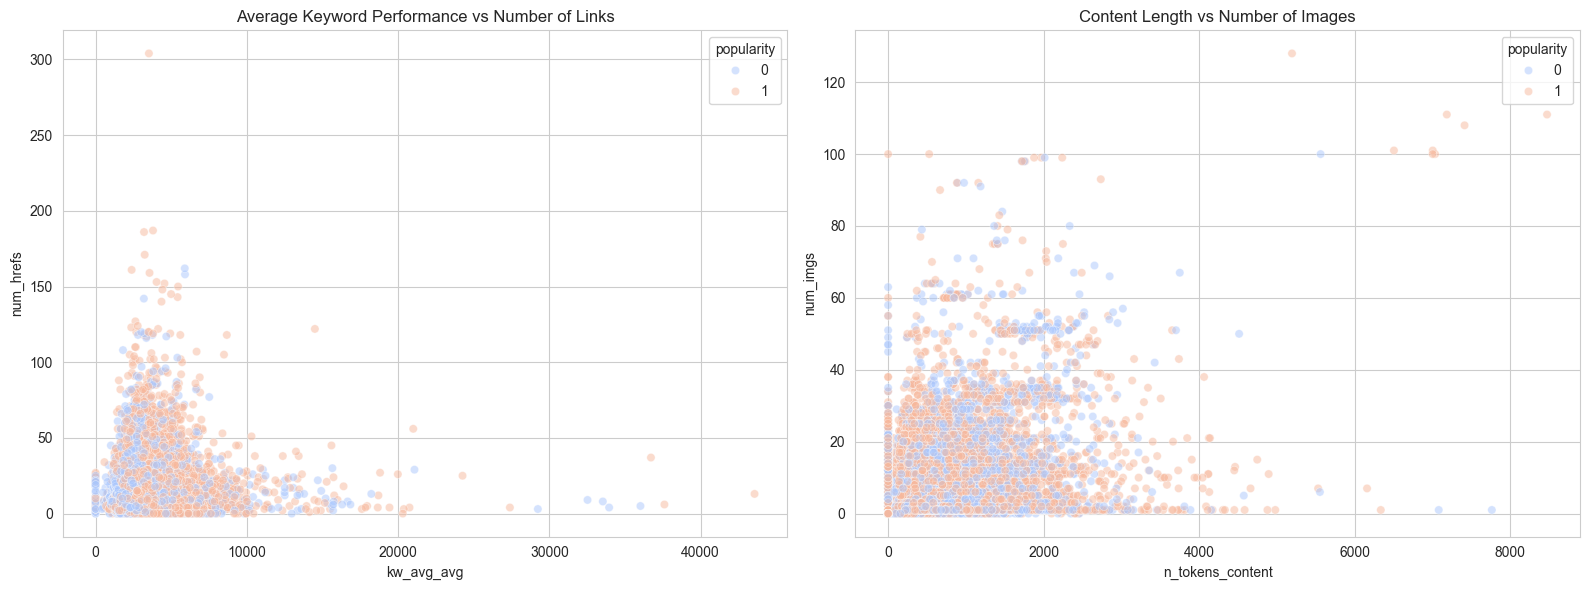

In [18]:
# Part A: Scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pair 1: Average keyword performance vs Number of links
sns.scatterplot(data=df, x='kw_avg_avg', y='num_hrefs', hue='popularity',
                palette='coolwarm', alpha=0.5, ax=ax1)
ax1.set_title('Average Keyword Performance vs Number of Links')

# Pair 2: Content length vs Number of images
sns.scatterplot(data=df, x='n_tokens_content', y='num_imgs', hue='popularity',
                palette='coolwarm', alpha=0.5, ax=ax2)
ax2.set_title('Content Length vs Number of Images')

plt.tight_layout()
plt.show()

#### PCA 2D Projection
We will use PCA to reduce the dimensionality of the scaled feature set to 2 components and visualize the variance captured.

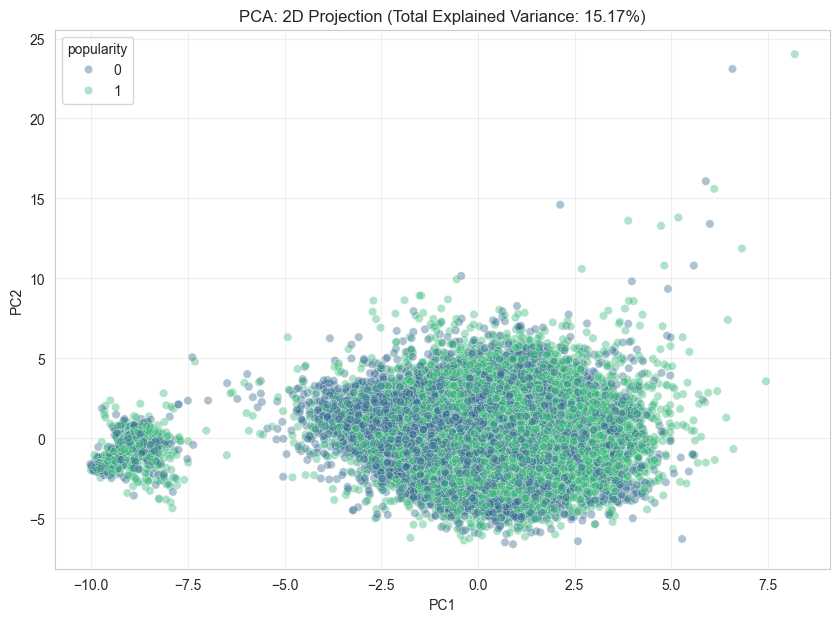

Explained variance by component: [0.08257287 0.06911461]


In [19]:
from sklearn.decomposition import PCA

# We use the scaled training data for PCA to ensure equal weighting
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_scaled)

# Create a DataFrame for visualization
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca['popularity'] = y_train.values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='popularity',
                palette='viridis', alpha=0.4)

# Calculate explained variance
exp_var = pca.explained_variance_ratio_.sum() * 100
plt.title(f'PCA: 2D Projection (Total Explained Variance: {exp_var:.2f}%)')
plt.grid(True, alpha=0.3)
plt.show()

print(f'Explained variance by component: {pca.explained_variance_ratio_}')

### Data Storage

In [ ]:
# Save Processed Data
import joblib
import os

# Ensure the subfolder exists
os.makedirs('../data/processed', exist_ok=True)

# Save splits
pd.DataFrame(X_train, columns=X.columns).to_csv('../data/processed/X_train.csv', index=False)
pd.DataFrame(X_test,  columns=X.columns).to_csv('../data/processed/X_test.csv',  index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv',   index=False)

# Save scaled versions
pd.DataFrame(X_train_scaled, columns=X.columns).to_csv('../data/processed/X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled,  columns=X.columns).to_csv('../data/processed/X_test_scaled.csv',  index=False)

# Save scaler
joblib.dump(scaler, '../data/processed/scaler.pkl')

print('All processed data saved to ../data/processed/')